In [8]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# RAG dataset build-readiness analysis

Analyzes the Drive archive at /content/drive/MyDrive/rag_data/rag_dataset_subsets.zip for the information needed to implement dataset adapters, ingestion, indexing, retrieval, and evaluation. It keeps corpus documents, queries, judgments/evidence, and expected answers conceptually separate. The source ZIP is never modified; reports are saved to Drive under rag_data/analysis_outputs/.


In [9]:
from __future__ import annotations

import hashlib, json, math, re, shutil, zipfile
from collections import Counter
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 100)
ARCHIVE = Path("/content/drive/MyDrive/rag_data/rag_dataset_subsets.zip")
EXTRACT = Path("/content/rag_dataset_analysis/extracted")
OUTPUT = Path("/content/drive/MyDrive/rag_data/analysis_outputs")
MAX_ROWS_PER_FILE = 5_000  #@param {type:"integer"}
CHUNK_SIZES = [256, 512, 1024]
OVERLAP = 0.15
VECTOR_DIMS = [384, 768, 1536]
if not ARCHIVE.is_file():
    raise FileNotFoundError(f"Archive not found: {ARCHIVE}")
OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"Archive: {ARCHIVE} ({ARCHIVE.stat().st_size / 2**20:,.2f} MiB)")


Archive: /content/drive/MyDrive/rag_data/rag_dataset_subsets.zip (1,059.27 MiB)


## 1. Validate, extract, inventory, and load

Extraction rejects path traversal. JSON, JSONL/NDJSON, CSV/TSV, and Parquet are supported with per-file error isolation. The first directory below the archive root is treated as the dataset name and remains visible for review.


In [10]:
SUFFIXES = {".json", ".jsonl", ".ndjson", ".csv", ".tsv", ".parquet"}

def human_bytes(n):
    n = float(n)
    for unit in ("B", "KiB", "MiB", "GiB", "TiB"):
        if n < 1024 or unit == "TiB": return f"{n:,.2f} {unit}"
        n /= 1024

def safe_extract(source, destination):
    if destination.exists(): shutil.rmtree(destination)
    destination.mkdir(parents=True)
    root = destination.resolve()
    with zipfile.ZipFile(source) as zf:
        bad = zf.testzip()
        if bad: raise zipfile.BadZipFile(f"CRC failure: {bad}")
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if root != target and root not in target.parents:
                raise ValueError(f"Unsafe member: {member.filename}")
        zf.extractall(destination)
        return zf.infolist()

members = safe_extract(ARCHIVE, EXTRACT)
ROOT = EXTRACT / "rag_dataset_subsets"
if not ROOT.is_dir(): ROOT = EXTRACT

def dataset_for(path):
    parts = path.relative_to(ROOT).parts
    return parts[0] if len(parts) > 1 else "unclassified"

inventory = pd.DataFrame([
    {"dataset": dataset_for(p), "path": str(p.relative_to(ROOT)),
     "suffix": p.suffix.lower() or "[none]", "bytes": p.stat().st_size,
     "tabular": p.suffix.lower() in SUFFIXES}
    for p in sorted(ROOT.rglob("*")) if p.is_file()
])
if inventory.empty: raise RuntimeError("The archive contains no files")
summary = inventory.groupby(["dataset", "suffix"], as_index=False).agg(files=("path","count"), bytes=("bytes","sum"))
summary["size"] = summary["bytes"].map(human_bytes)
display(summary)
inventory.to_csv(OUTPUT / "file_inventory.csv", index=False)

def record(value): return value if isinstance(value, dict) else {"value": value}
def load(path):
    suffix = path.suffix.lower()
    if suffix in {".jsonl", ".ndjson"}:
        rows=[]
        with path.open(encoding="utf-8-sig") as f:
            for line_number, line in enumerate(f, 1):
                if not line.strip(): continue
                try: rows.append(record(json.loads(line)))
                except json.JSONDecodeError as exc: raise ValueError(f"line {line_number}: {exc}") from exc
                if len(rows) >= MAX_ROWS_PER_FILE: break
        return rows
    if suffix == ".json":
        value=json.loads(path.read_text(encoding="utf-8-sig"))
        if isinstance(value,list): return [record(x) for x in value[:MAX_ROWS_PER_FILE]]
        if isinstance(value,dict):
            for key in ("records","rows","data","examples"):
                if isinstance(value.get(key),list): return [record(x) for x in value[key][:MAX_ROWS_PER_FILE]]
        return [record(value)]
    if suffix in {".csv",".tsv"}:
        return pd.read_csv(path, sep="\t" if suffix==".tsv" else ",", nrows=MAX_ROWS_PER_FILE).to_dict("records")
    if suffix==".parquet": return pd.read_parquet(path).head(MAX_ROWS_PER_FILE).to_dict("records")
    raise ValueError(f"Unsupported: {suffix}")

records_by_file={}; load_rows=[]
for row in inventory[inventory.tabular].itertuples(index=False):
    try:
        rows=load(ROOT/row.path); records_by_file[row.path]=rows
        load_rows.append({"dataset":row.dataset,"path":row.path,"rows":len(rows),"status":"loaded","error":""})
    except Exception as exc:
        load_rows.append({"dataset":row.dataset,"path":row.path,"rows":0,"status":"error","error":f"{type(exc).__name__}: {exc}"})
load_report=pd.DataFrame(load_rows)
display(load_report)
load_report.to_csv(OUTPUT/"load_report.csv",index=False)
print(f"Loaded {sum(map(len,records_by_file.values())):,} rows from {len(records_by_file)} files")


,dataset,suffix,files,bytes,size
0,files,.jsonl,1085,1613524299,1.50 GiB
1,huggingface,.jsonl,9,2580860193,2.40 GiB
2,unclassified,.csv,1,227845,222.50 KiB


,dataset,path,rows,status,error
0,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,5000,loaded,
1,files,files/BEIR/arguana/qrels/test.tsv.sample.jsonl,1406,loaded,
2,files,files/BEIR/arguana/queries.jsonl.sample.jsonl,1406,loaded,
3,files,files/BEIR/fiqa/corpus.jsonl.sample.jsonl,5000,loaded,
4,files,files/BEIR/fiqa/qrels/dev.tsv.sample.jsonl,1238,loaded,
...,...,...,...,...,...
1090,huggingface,huggingface/FEVER/v1_0/unlabelled_test.jsonl,5000,loaded,
1091,huggingface,huggingface/HotpotQA/dataset/train.jsonl,5000,loaded,
1092,huggingface,huggingface/HotpotQA/dataset/validation.jsonl,5000,loaded,
1093,huggingface,huggingface/Natural_Questions/dataset/data.jsonl,5000,loaded,


Loaded 191,522 rows from 1095 files


## 2. Schema completeness and candidate application mappings

Nested dictionaries are flattened to dot paths. Role inference is deliberately heuristic and must be checked against official schemas. Its output proposes separate fields for CorpusDocument, BenchmarkQuery, RelevanceJudgment/evidence, and ExpectedAnswer adapters; it does not treat a combined benchmark record as an ingestion document.


In [11]:
def flatten(value,prefix=""):
    out={}
    for key,item in value.items():
        name=f"{prefix}.{key}" if prefix else str(key)
        if isinstance(item,dict): out.update(flatten(item,name) or {name:item})
        else: out[name]=item
    return out

def null(x): return x is None or (isinstance(x,float) and math.isnan(x))
def typename(x):
    if null(x): return "null"
    if isinstance(x,bool): return "boolean"
    if isinstance(x,int): return "integer"
    if isinstance(x,float): return "number"
    if isinstance(x,str): return "string"
    if isinstance(x,list): return "array"
    if isinstance(x,dict): return "object"
    return type(x).__name__

flat_by_file={}; schema_rows=[]
for path,rows in records_by_file.items():
    flat_by_file[path]=items=[flatten(x) for x in rows]
    fields=sorted({k for item in items for k in item})
    for field in fields:
        present=[item[field] for item in items if field in item]
        valid=[x for x in present if not null(x)]
        types=Counter(map(typename,present))
        schema_rows.append({"dataset":dataset_for(ROOT/path),"path":path,"field":field,"rows":len(items),
          "presence_rate":len(present)/len(items) if items else np.nan,
          "non_null_rate":len(valid)/len(items) if items else np.nan,
          "types":", ".join(f"{k}:{v}" for k,v in types.most_common()),
          "distinct_sample":len({repr(x) for x in valid[:1000]})})
schema=pd.DataFrame(schema_rows)
if schema.empty: raise RuntimeError("No fields found")
display(schema.sort_values(["dataset","path","presence_rate"],ascending=[True,True,False]))
schema.to_csv(OUTPUT/"schema_profile.csv",index=False)

PATTERNS={
 "document_id":[r"(^|\.)(doc_id|document_id|corpus_id|passage_id|context_id|pid|_id)$",r"(^|\.)(id|title)$"],
 "document_text":[r"(^|\.)(text|content|contents|body|passage|paragraph|document|context|article)$",r"(^|\.)(sentences|paragraphs)$"],
 "query_id":[r"(^|\.)(query_id|question_id|qid|claim_id|example_id|sample_id)$",r"(^|\.)(id|_id)$"],
 "query_text":[r"(^|\.)(query|question|claim|prompt|user_input|input)$"],
 "answer":[r"(^|\.)(answer|answers|response|reference_answer|gold_answer|output|label)$"],
 "document_link":[r"(^|\.)(doc_id|document_id|corpus_id|passage_id|ctx_id|context_id|pid)$",r"(^|\.)(positive_ctxs|supporting_facts|evidence|qrels)$"],
 "relevance":[r"(^|\.)(score|relevance|rel|label|gold|is_relevant)$"]}

def candidates(group,role):
    scored=[]
    for field in group.field:
        score=max([100-i*10 for i,p in enumerate(PATTERNS[role]) if re.search(p,field.lower())] or [0])
        if score: scored.append((score,field))
    return [field for _,field in sorted(scored,reverse=True)][:5]

role_rows=[]
# Iterate over every loaded file, including files whose sampled records flatten to no fields.
for path in sorted(flat_by_file):
    dataset=dataset_for(ROOT/path)
    group=schema[schema["path"].eq(path)]
    found={role:candidates(group,role) for role in PATTERNS}
    assets=[]
    if found["document_text"]: assets.append("corpus_document")
    if found["query_text"]: assets.append("query")
    if found["document_link"] or found["relevance"]: assets.append("relevance_judgment/evidence")
    if found["answer"]: assets.append("expected_answer")
    strong=(found["document_text"] and found["document_id"]) or (found["query_text"] and found["query_id"])
    role_rows.append({"dataset":dataset,"path":path,"rows_loaded":len(flat_by_file[path]),"schema_fields":len(group),"inferred_assets":", ".join(assets) or "unknown",
      "confidence":"high" if strong else "medium" if assets else "manual_review",
      **{role+"_fields":", ".join(values) for role,values in found.items()}})
roles=pd.DataFrame(role_rows)
display(roles)
roles.to_csv(OUTPUT/"candidate_asset_mappings.csv",index=False)


,dataset,path,field,rows,presence_rate,non_null_rate,types,distinct_sample
0,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,_id,5000,1.0,1.000000,string:5000,1000
1,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,metadata,5000,1.0,1.000000,object:5000,1
2,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,text,5000,1.0,1.000000,string:5000,998
3,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,title,5000,1.0,1.000000,string:5000,147
4,files,files/BEIR/arguana/qrels/test.tsv.sample.jsonl,corpus-id,1406,1.0,1.000000,string:1406,1000
...,...,...,...,...,...,...,...,...
66883,unclassified,subset_manifest.csv,error,1094,1.0,0.264168,"null:805, string:289",8
66884,unclassified,subset_manifest.csv,output,1094,1.0,1.000000,string:1094,1000
66885,unclassified,subset_manifest.csv,rows,1094,1.0,1.000000,integer:1094,18
66886,unclassified,subset_manifest.csv,source,1094,1.0,1.000000,string:1094,1000


,dataset,path,rows_loaded,schema_fields,inferred_assets,confidence,document_id_fields,document_text_fields,query_id_fields,query_text_fields,answer_fields,document_link_fields,relevance_fields
0,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,5000,4,corpus_document,high,"_id, title",text,_id,,,,
1,files,files/BEIR/arguana/qrels/test.tsv.sample.jsonl,1406,3,relevance_judgment/evidence,medium,,,,,,,score
2,files,files/BEIR/arguana/queries.jsonl.sample.jsonl,1406,3,corpus_document,high,_id,text,_id,,,,
3,files,files/BEIR/fiqa/corpus.jsonl.sample.jsonl,5000,4,corpus_document,high,"_id, title",text,_id,,,,
4,files,files/BEIR/fiqa/qrels/dev.tsv.sample.jsonl,1238,3,relevance_judgment/evidence,medium,,,,,,,score
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,huggingface,huggingface/FEVER/v1_0/unlabelled_test.jsonl,5000,7,"query, relevance_judgment/evidence, expected_answer",high,id,,id,claim,label,,label
1091,huggingface,huggingface/HotpotQA/dataset/train.jsonl,5000,9,"corpus_document, query, expected_answer",high,"supporting_facts.title, id, context.title",context.sentences,id,question,answer,,
1092,huggingface,huggingface/HotpotQA/dataset/validation.jsonl,5000,9,"corpus_document, query, expected_answer",high,"supporting_facts.title, id, context.title",context.sentences,id,question,answer,,
1093,huggingface,huggingface/Natural_Questions/dataset/data.jsonl,5000,19,corpus_document,high,"id, document.title, annotations.id",question.text,"id, annotations.id",,,,


## 3. Text lengths, duplicates, chunk capacity, and dataset readiness

Approximate tokens are ceil(characters / 4), suitable only for early planning. Recompute with the selected embedding tokenizer. Raw vector estimates exclude ANN graphs, sparse indexes, stored text/metadata, replicas, and filesystem overhead.


,dataset,path,rows,mapping_confidence,document_id_field,document_id_nonempty_rate,document_id_duplicate_rate,query_id_field,query_id_nonempty_rate,query_id_duplicate_rate,document_text_field,document_text_nonempty_rate,document_text_duplicate_rate,query_text_field,query_text_nonempty_rate,query_text_duplicate_rate,answer_field,answer_nonempty_rate,answer_duplicate_rate
0,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,5000,high,_id,1.0,0.0000,_id,1.0,0.0,text,1.000,0.005800,,0.0,NaN,,0.0,NaN
1,files,files/BEIR/arguana/qrels/test.tsv.sample.jsonl,1406,medium,,0.0,NaN,,0.0,NaN,,0.000,NaN,,0.0,NaN,,0.0,NaN
2,files,files/BEIR/arguana/queries.jsonl.sample.jsonl,1406,high,_id,1.0,0.0000,_id,1.0,0.0,text,1.000,0.076814,,0.0,NaN,,0.0,NaN
3,files,files/BEIR/fiqa/corpus.jsonl.sample.jsonl,5000,high,_id,1.0,0.0000,_id,1.0,0.0,text,0.999,0.000000,,0.0,NaN,,0.0,NaN
4,files,files/BEIR/fiqa/qrels/dev.tsv.sample.jsonl,1238,medium,,0.0,NaN,,0.0,NaN,,0.000,NaN,,0.0,NaN,,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,huggingface,huggingface/FEVER/v1_0/unlabelled_test.jsonl,5000,high,id,1.0,0.0000,id,1.0,0.0,,0.000,NaN,claim,1.0,0.0046,label,0.0,NaN
1091,huggingface,huggingface/HotpotQA/dataset/train.jsonl,5000,high,supporting_facts.title,1.0,0.0032,id,1.0,0.0,context.sentences,1.000,0.000000,question,1.0,0.0000,answer,1.0,0.1834
1092,huggingface,huggingface/HotpotQA/dataset/validation.jsonl,5000,high,supporting_facts.title,1.0,0.0042,id,1.0,0.0,context.sentences,1.000,0.000000,question,1.0,0.0000,answer,1.0,0.1294
1093,huggingface,huggingface/Natural_Questions/dataset/data.jsonl,5000,high,id,1.0,0.0000,id,1.0,0.0,question.text,1.000,0.000000,,0.0,NaN,,0.0,NaN


,dataset,path,role,field,values,token_median,token_p95,token_max
0,files,files/BEIR/arguana/corpus.jsonl.sample.jsonl,document_text,text,5000,224.0,491.05,1669
1,files,files/BEIR/arguana/queries.jsonl.sample.jsonl,document_text,text,1406,270.0,540.75,1375
2,files,files/BEIR/fiqa/corpus.jsonl.sample.jsonl,document_text,text,4995,134.0,531.60,3270
3,files,files/BEIR/fiqa/queries.jsonl.sample.jsonl,document_text,text,5000,15.0,26.00,42
4,files,files/BEIR/nfcorpus/corpus.jsonl.sample.jsonl,document_text,text,3633,380.0,557.00,2485
...,...,...,...,...,...,...,...,...
115,huggingface,huggingface/HotpotQA/dataset/validation.jsonl,answer,answer,5000,4.0,9.00,41
116,huggingface,huggingface/HotpotQA/dataset/validation.jsonl,document_text,context.sentences,5000,1345.0,2023.00,4100
117,huggingface,huggingface/HotpotQA/dataset/validation.jsonl,query_text,question,5000,22.0,39.00,72
118,huggingface,huggingface/Natural_Questions/dataset/data.jsonl,document_text,question.text,5000,12.0,19.00,25


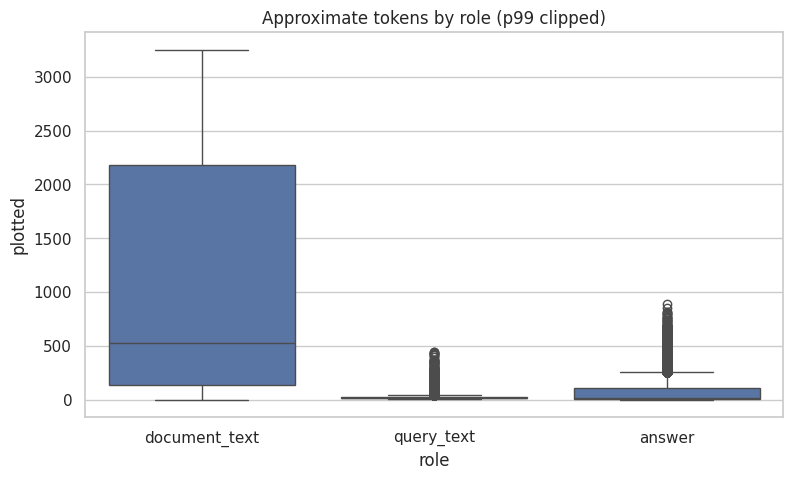

,dataset,chunk_tokens,estimated_chunks,dimensions,raw_vector_bytes,raw_vector_size
0,files,256,353462,384,542917632,517.77 MiB
1,files,256,353462,768,1085835264,1.01 GiB
2,files,256,353462,1536,2171670528,2.02 GiB
3,files,512,191329,384,293881344,280.27 MiB
4,files,512,191329,768,587762688,560.53 MiB
5,files,512,191329,1536,1175525376,1.09 GiB
6,files,1024,115522,384,177441792,169.22 MiB
7,files,1024,115522,768,354883584,338.44 MiB
8,files,1024,115522,1536,709767168,676.89 MiB
9,huggingface,256,70744,384,108662784,103.63 MiB


,dataset,files,corpus_files,query_files,judgment_files,answer_files,manual_review_files,retrieval_eval_candidate,answer_eval_candidate
0,files,1085,17,44,11,41,1020,True,True
1,huggingface,9,3,8,6,8,0,True,True
2,unclassified,1,0,0,0,1,0,False,False


In [12]:
def project(x):
    if null(x): return ""
    if isinstance(x,str): return x.strip()
    if isinstance(x,(list,tuple)): return " ".join(filter(None,map(project,x)))
    if isinstance(x,dict): return " ".join(filter(None,map(project,x.values())))
    return str(x)
def tokens(text): return math.ceil(len(text)/4) if text else 0

def dupe_rate(values):
    values=[json.dumps(x,sort_keys=True,default=str) for x in values if x is not None]
    return 1-len(set(values))/len(values) if values else np.nan

lookup=roles.set_index("path").to_dict("index"); text_rows=[]; quality=[]; fallback_paths=[]
for path,rows in flat_by_file.items():
    mapping=lookup.get(path)
    if mapping is None:
        # Keep analysis running if Step 2 used stale state or a file had no schema fields.
        fallback_paths.append(path)
        mapping={"dataset":dataset_for(ROOT/path),"confidence":"manual_review",
          **{role+"_fields":"" for role in PATTERNS}}
    result={"dataset":mapping["dataset"],"path":path,"rows":len(rows),
      "mapping_confidence":mapping.get("confidence","manual_review")}
    for role in ("document_id","query_id","document_text","query_text","answer"):
        fields=[x for x in mapping[role+"_fields"].split(", ") if x]
        field=fields[0] if fields else None
        values=[r.get(field) for r in rows] if field else []
        nonempty=[x for x in values if project(x)]
        checked=[hashlib.sha256(re.sub(r"\s+"," ",project(x)).lower().encode()).hexdigest() for x in nonempty] if role.endswith("_text") else nonempty
        result[role+"_field"]=field or ""; result[role+"_nonempty_rate"]=len(nonempty)/len(rows) if rows else np.nan
        result[role+"_duplicate_rate"]=dupe_rate(checked)
    quality.append(result)
    for role in ("document_text","query_text","answer"):
        for field in [x for x in mapping[role+"_fields"].split(", ") if x][:3]:
            for row in rows:
                text=project(row.get(field))
                if text: text_rows.append({"dataset":mapping["dataset"],"path":path,"role":role,"field":field,"characters":len(text),"approx_tokens":tokens(text)})
quality=pd.DataFrame(quality); texts=pd.DataFrame(text_rows)
if fallback_paths:
    print(f"Warning: {len(fallback_paths)} file(s) lacked a Step 2 mapping and were marked for manual review.")
    display(pd.DataFrame({"unmapped_path":fallback_paths}))
display(quality); quality.to_csv(OUTPUT/"identifier_duplicate_profile.csv",index=False)
if texts.empty:
    text_summary=pd.DataFrame(); capacity=pd.DataFrame(); print("No candidate text fields found")
else:
    text_summary=texts.groupby(["dataset","path","role","field"]).agg(values=("characters","size"),token_median=("approx_tokens","median"),token_p95=("approx_tokens",lambda x:x.quantile(.95)),token_max=("approx_tokens","max")).reset_index()
    display(text_summary); text_summary.to_csv(OUTPUT/"text_length_profile.csv",index=False)
    clipped=texts.assign(plotted=lambda x:x.approx_tokens.clip(upper=max(1,x.approx_tokens.quantile(.99))))
    plt.figure(figsize=(9,5)); sns.boxplot(data=clipped,x="role",y="plotted"); plt.title("Approximate tokens by role (p99 clipped)"); plt.show()
    cap=[]
    for dataset,group in texts[texts.role=="document_text"].groupby("dataset"):
        for size in CHUNK_SIZES:
            stride=max(1,round(size*(1-OVERLAP)))
            chunks=int(group.approx_tokens.map(lambda n: 1 if n<=size else 1+math.ceil((n-size)/stride)).sum())
            for dims in VECTOR_DIMS: cap.append({"dataset":dataset,"chunk_tokens":size,"estimated_chunks":chunks,"dimensions":dims,"raw_vector_bytes":chunks*dims*4,"raw_vector_size":human_bytes(chunks*dims*4)})
    capacity=pd.DataFrame(cap); display(capacity); capacity.to_csv(OUTPUT/"sample_capacity_estimates.csv",index=False)

readiness=(roles.assign(corpus=roles.inferred_assets.str.contains("corpus_document"),query=roles.inferred_assets.str.contains("query"),judgment=roles.inferred_assets.str.contains("relevance_judgment"),answer=roles.inferred_assets.str.contains("expected_answer"),manual=roles.confidence.eq("manual_review")).groupby("dataset",as_index=False).agg(files=("path","count"),corpus_files=("corpus","sum"),query_files=("query","sum"),judgment_files=("judgment","sum"),answer_files=("answer","sum"),manual_review_files=("manual","sum")))
readiness["retrieval_eval_candidate"]=(readiness.corpus_files>0)&(readiness.query_files>0)&(readiness.judgment_files>0)
readiness["answer_eval_candidate"]=(readiness.query_files>0)&(readiness.answer_files>0)
display(readiness); readiness.to_csv(OUTPUT/"dataset_readiness.csv",index=False)


## 4. Build recommendations and export

The machine-readable report is tied to the exact archive checksum. Recommendations are evidence from these capped subsets, not final production sizing or a substitute for official dataset documentation.


In [13]:
recommendations=[]
failed=load_report[load_report.status!="loaded"]
if len(failed): recommendations.append(f"Repair parsers for {len(failed)} failed file(s); do not silently exclude them.")
manual=roles[roles.confidence=="manual_review"]
if len(manual): recommendations.append(f"Manually map {len(manual)} file(s) with no confident asset inference.")
mixed=schema[schema.types.str.count(",")>0]
if len(mixed): recommendations.append(f"Normalize or validate {len(mixed)} mixed-type field/file combinations.")
incomplete=schema[(schema.presence_rate<.95)|(schema.non_null_rate<.95)]
if len(incomplete): recommendations.append(f"Define missing-value policy for {len(incomplete)} field/file combinations below 95% completeness.")
if not text_summary.empty:
    long=text_summary[(text_summary.role=="document_text")&(text_summary.token_p95>512)]
    if len(long): recommendations.append(f"Use structure-aware chunking and stable locators: {len(long)} document fields exceed 512 approximate tokens at p95.")
dupcols=[x for x in quality if x.endswith("_duplicate_rate")]
high=quality[quality[dupcols].fillna(0).max(axis=1)>.05]
if len(high): recommendations.append(f"Add deterministic deduplication tests for {len(high)} files above 5% exact duplicates.")
recommendations += [
 "Implement a dataset-family adapter that emits separate corpus, query, judgment/evidence, and expected-answer streams.",
 "Validate IDs and cross-stream joins on 25-100 query smoke fixtures before indexing.",
 "Tune only on development/validation splits; reserve test splits for final evaluation.",
 "Recalculate lengths with the chosen tokenizer and pilot OpenSearch size and latency.",
 "Preserve raw evidence and locators; generated context is a retrieval aid, never evidence."]
display(Markdown("\n".join(f"{i}. {x}" for i,x in enumerate(recommendations,1))))

def file_hash(path):
    digest=hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda:f.read(2**20),b""): digest.update(block)
    return digest.hexdigest()
def records(frame): return [] if frame.empty else json.loads(frame.to_json(orient="records"))
report={"report_schema_version":"rag-dataset-build-readiness-v1","source":{"path":str(ARCHIVE),"sha256":file_hash(ARCHIVE),"size_bytes":ARCHIVE.stat().st_size},"configuration":{"max_rows_per_file":MAX_ROWS_PER_FILE,"chunk_sizes":CHUNK_SIZES,"overlap":OVERLAP,"vector_dimensions":VECTOR_DIMS,"token_estimate":"ceil(characters/4)"},"counts":{"zip_members":len(members),"files":len(inventory),"datasets":inventory.dataset.nunique(),"loaded_files":len(records_by_file),"loaded_rows":sum(map(len,records_by_file.values()))},"dataset_readiness":records(readiness),"candidate_mappings":records(roles),"recommendations":recommendations,"limitations":["Capped subsets do not represent full-data counts.","Field inference requires official-schema review.","Token and vector sizing are approximations."]}
report_path=OUTPUT/"rag_dataset_build_readiness_report.json"
report_path.write_text(json.dumps(report,ensure_ascii=False,indent=2),encoding="utf-8")
files=sorted(p for p in OUTPUT.glob("*") if p.is_file())
display(pd.DataFrame({"output":[p.name for p in files],"size":[human_bytes(p.stat().st_size) for p in files]}))
print(f"Complete: {report_path}")


1. Manually map 1020 file(s) with no confident asset inference.
2. Normalize or validate 504 mixed-type field/file combinations.
3. Define missing-value policy for 606 field/file combinations below 95% completeness.
4. Use structure-aware chunking and stable locators: 14 document fields exceed 512 approximate tokens at p95.
5. Add deterministic deduplication tests for 36 files above 5% exact duplicates.
6. Implement a dataset-family adapter that emits separate corpus, query, judgment/evidence, and expected-answer streams.
7. Validate IDs and cross-stream joins on 25-100 query smoke fixtures before indexing.
8. Tune only on development/validation splits; reserve test splits for final evaluation.
9. Recalculate lengths with the chosen tokenizer and pilot OpenSearch size and latency.
10. Preserve raw evidence and locators; generated context is a retrieval aid, never evidence.

,output,size
0,candidate_asset_mappings.csv,130.56 KiB
1,dataset_readiness.csv,243.00 B
2,file_inventory.csv,102.03 KiB
3,identifier_duplicate_profile.csv,140.11 KiB
4,load_report.csv,93.92 KiB
5,rag_dataset_build_readiness_report.json,512.13 KiB
6,sample_capacity_estimates.csv,886.00 B
7,schema_profile.csv,6.02 MiB
8,text_length_profile.csv,12.66 KiB


Complete: /content/drive/MyDrive/rag_data/analysis_outputs/rag_dataset_build_readiness_report.json
